# Machine Learning Model for AI Insurance Agent

## Model Based on Classification

### Importing necessary libraries

In [70]:
!pip install matplotlib
!pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [68]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, mean_squared_error, r2_score
import datetime
from datetime import datetime, timedelta
import seaborn as sns
import joblib

### Import Dataset

In [2]:
a = pd.read_csv('customer.csv')
b = pd.read_csv('policy.csv')

In [3]:
a.head()

,customer_id,name,phone,language_pref,time_zone
0,1,Customer_1,916503455352,en,Asia/Kolkata
1,2,Customer_2,916452043932,en,Asia/Kolkata
2,3,Customer_3,917057149062,en,Asia/Kolkata
3,4,Customer_4,916379205036,en,Asia/Kolkata
4,5,Customer_5,919970597903,en,Asia/Kolkata


In [4]:
b.head()

,policy_id,customer_id,premium_amount,due_date,status,promise_date
0,1,159,3275.88,2025-11-15,active,NaN
1,2,280,1650.51,2025-09-28,overdue,NaN
2,3,76,4065.85,2025-07-07,overdue,NaN
3,4,198,1616.30,2025-08-03,active,NaN
4,5,65,3746.97,2025-07-24,active,NaN


### Create a new table with both datasets

In [5]:
merged = pd.merge(a, b, on='customer_id', how='left')

In [6]:
merged.head()

,customer_id,name,phone,language_pref,time_zone,policy_id,premium_amount,due_date,status,promise_date
0,1,Customer_1,916503455352,en,Asia/Kolkata,NaN,NaN,NaN,NaN,NaN
1,2,Customer_2,916452043932,en,Asia/Kolkata,NaN,NaN,NaN,NaN,NaN
2,3,Customer_3,917057149062,en,Asia/Kolkata,81.0,2675.88,2025-10-08,overdue,NaN
3,4,Customer_4,916379205036,en,Asia/Kolkata,NaN,NaN,NaN,NaN,NaN
4,5,Customer_5,919970597903,en,Asia/Kolkata,50.0,3886.85,2025-09-10,active,NaN


### Checking Null Values

In [7]:
merged.isnull().sum()

customer_id         0
name                0
phone               0
language_pref       0
time_zone           0
policy_id         110
premium_amount    110
due_date          110
status            110
promise_date      410
dtype: int64

### Changing null values for merged table (Except promise_date)

In [8]:
merged['promise_date'] = merged['promise_date'].replace('', np.nan)

In [9]:
merged['promise_date'].isnull().sum()

410

In [10]:
no_policy = merged['policy_id'].isna()

In [11]:
no_policy.sum()

110

In [12]:
if no_policy.sum() > 0:
    policy = merged[~no_policy]
    
    premium_mean = policy['premium_amount'].mean()
    premium_std = policy['premium_amount'].std()
    premium_min = policy['premium_amount'].min()
    premium_max = policy['premium_amount'].max()

    stat = policy['status'].value_counts(normalize=True).to_dict()
    
    # Get next policy_id
    next_policy_id = policy['policy_id'].max() + 1
    
    # Generate data for customers without policies
    for idx in merged[no_policy].index:
        # Assign policy_id
        merged.loc[idx, 'policy_id'] = next_policy_id
        next_policy_id += 1
        
        # Generate random premium amount (normal distribution)
        premium = np.random.normal(premium_mean, premium_std)
        premium = np.clip(premium, premium_min, premium_max)
        merged.loc[idx, 'premium_amount'] = round(premium, 2)
        
        # Generate random due date (between -60 days and +60 days from today)
        days_offset = np.random.randint(-60, 60)
        due_date = (datetime.now() + timedelta(days=days_offset)).strftime('%Y-%m-%d')
        merged.loc[idx, 'due_date'] = due_date
        
        # Generate random status based on existing distribution
        status = np.random.choice(
            list(stat.keys()), 
            p=list(stat.values())
        )
        merged.loc[idx, 'status'] = status
        
        # Generate promise_date based on status
        if status == 'promise_pending':
            # 100% of promise_pending should have a promise date
            promise_days = np.random.randint(1, 30)
            promise_date = (datetime.now() + timedelta(days=promise_days)).strftime('%Y-%m-%d')
            merged.loc[idx, 'promise_date'] = promise_date
        elif status == 'overdue':
            # 20% of overdue cases might have a promise date
            if np.random.random() < 0.2:
                promise_days = np.random.randint(1, 30)
                promise_date = (datetime.now() + timedelta(days=promise_days)).strftime('%Y-%m-%d')
                merged.loc[idx, 'promise_date'] = promise_date
            else:
                merged.loc[idx, 'promise_date'] = np.nan
        else:  # active
            merged.loc[idx, 'promise_date'] = np.nan
    
    print(f"\nGenerated policies for {no_policy.sum()} customers")


Generated policies for 110 customers


C:\Users\itsme\AppData\Local\Temp\ipykernel_8912\2228646233.py:48: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2026-02-24' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  merged.loc[idx, 'promise_date'] = promise_date


In [13]:
policy.head()

,customer_id,name,phone,language_pref,time_zone,policy_id,premium_amount,due_date,status,promise_date
2,3,Customer_3,917057149062,en,Asia/Kolkata,81.0,2675.88,2025-10-08,overdue,NaN
4,5,Customer_5,919970597903,en,Asia/Kolkata,50.0,3886.85,2025-09-10,active,NaN
5,5,Customer_5,919970597903,en,Asia/Kolkata,54.0,4303.00,2025-12-29,overdue,NaN
8,8,Customer_8,917412968662,en,America/New_York,253.0,3105.73,2025-11-30,overdue,NaN
9,8,Customer_8,917412968662,en,America/New_York,287.0,2450.30,2025-07-04,overdue,NaN


In [85]:
policy['premium_amount'].min(), policy['premium_amount'].max(), policy['premium_amount'].mean(), policy['premium_amount'].std()

(1505.92, 4485.91, 2944.2567, 859.0705145146535)

In [14]:
merged['policy_id'] = merged['policy_id'].astype(int)

In [15]:
merged['policy_id'].isnull().sum()

0

In [16]:
merged.isnull().sum()

customer_id         0
name                0
phone               0
language_pref       0
time_zone           0
policy_id           0
premium_amount      0
due_date            0
status              0
promise_date      386
dtype: int64

### Working on Due Date

In [17]:
merged['due_date'] = pd.to_datetime(merged['due_date'])


In [18]:
today = pd.Timestamp.now()
merged['days_overdue'] = (today - merged['due_date']).dt.days
merged['days_overdue'] = merged['days_overdue'].clip(lower=0)

In [19]:
merged.loc[merged['status'] == 'active', 'days_overdue'] = 0


In [20]:
merged['promise_risk'] = merged['promise_date'].isna().map({True: 0.5, False: 0.1})


### Working on overdue

In [21]:
max_days = 180
merged['days_risk'] = (merged['days_overdue'] / max_days).clip(0, 1) * 0.3


### Working on Risk Factor

In [22]:
min_premium = merged['premium_amount'].min()
max_premium = merged['premium_amount'].max()
merged['premium_risk'] = ((merged['premium_amount'] - min_premium) / (max_premium - min_premium)) * 0.2

In [23]:
merged['risk_factor'] = (merged['promise_risk'] + 
                             merged['days_risk'] + 
                             merged['premium_risk'])
merged['risk_factor'] = merged['risk_factor'].clip(0, 1)


### Final Database

In [24]:
final = merged[[
    'policy_id', 'customer_id', 'name', 'phone', 
    'premium_amount', 'due_date', 'status', 'promise_date',
    'days_overdue', 'risk_factor', 'language_pref', 'time_zone'
]].copy()

In [25]:
final = final.sort_values('risk_factor', ascending=False).reset_index(drop=True)

### Checking on the Data Pairplot

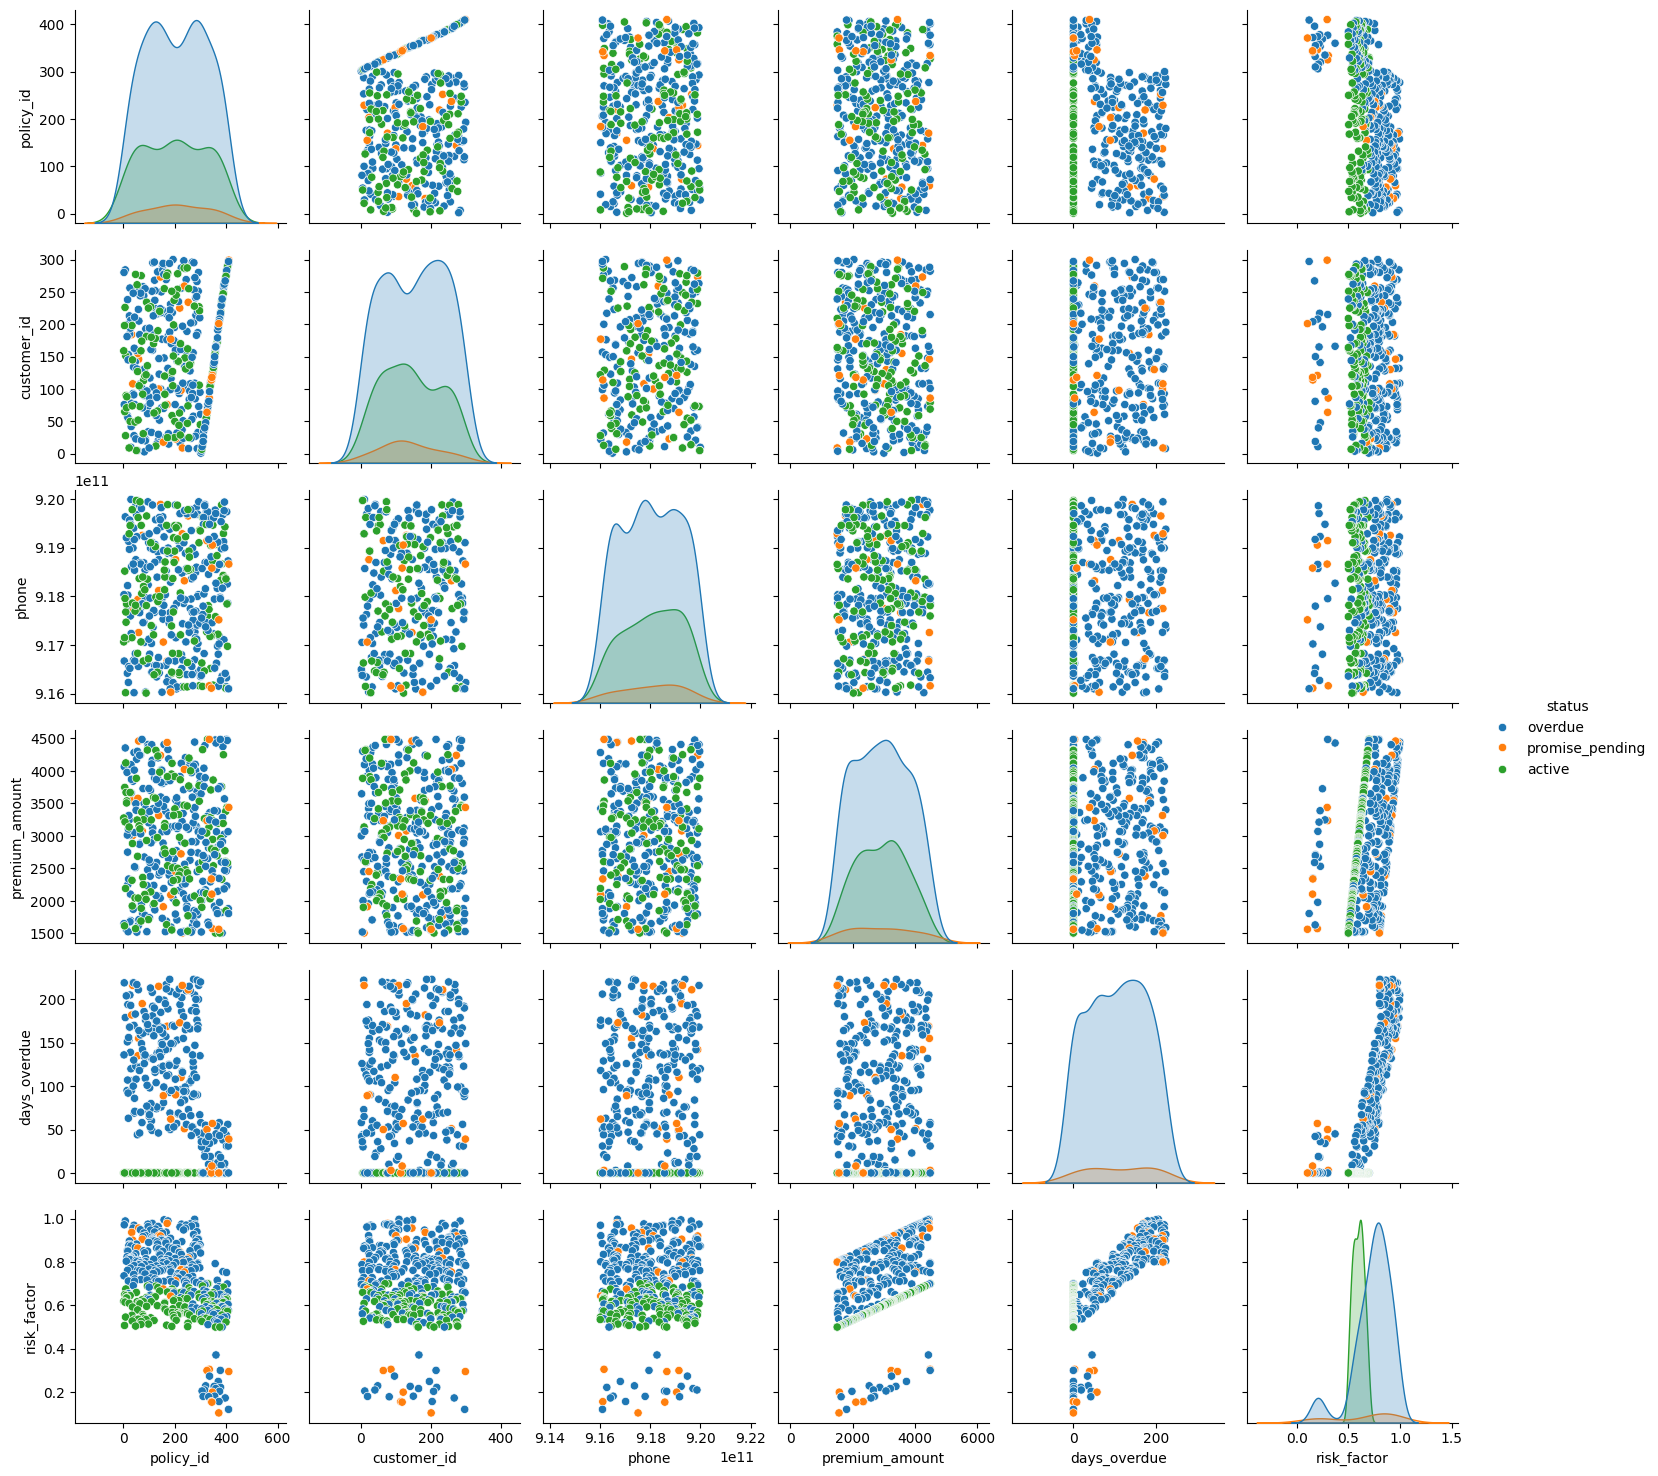

In [26]:
sns.pairplot(final, hue='status')

In [27]:
final.isnull().sum()

policy_id           0
customer_id         0
name                0
phone               0
premium_amount      0
due_date            0
status              0
promise_date      386
days_overdue        0
risk_factor         0
language_pref       0
time_zone           0
dtype: int64

### Working on training

In [28]:
X = merged.drop(columns=[
    'risk_factor', 'name', 'phone', 'time_zone', 'status', 
    'promise_date', 'language_pref', 'due_date', 'customer_id', 'policy_id'
], axis=1)
y = merged['risk_factor']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [30]:
X_train.count()

premium_amount    328
days_overdue      328
promise_risk      328
days_risk         328
premium_risk      328
dtype: int64

In [31]:
X_test.count()

premium_amount    82
days_overdue      82
promise_risk      82
days_risk         82
premium_risk      82
dtype: int64

In [32]:
y_train.count()

328

In [33]:
y_test.count()

82

In [34]:
X_train.head()

,premium_amount,days_overdue,promise_risk,days_risk,premium_risk
108,2379.36,53,0.5,0.088333,0.058620
378,2191.08,99,0.5,0.165000,0.045984
247,3247.02,0,0.5,0.000000,0.116853
175,2686.33,0,0.5,0.000000,0.079222
3,1521.74,36,0.5,0.060000,0.001062


In [35]:
y_train.head()

108    0.646954
378    0.710984
247    0.616853
175    0.579222
3      0.561062
Name: risk_factor, dtype: float64

In [44]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [46]:
y_pred = lr_model.predict(X_test)

In [47]:
y_pred

array([0.59670167, 0.76509267, 0.61310374, 0.81383914, 0.59353857,
       0.89325713, 0.56954117, 0.72647861, 0.51385911, 0.78327171,
       0.88042133, 0.69955644, 0.65119581, 0.85184583, 0.61932456,
       0.7       , 0.65121527, 0.71204621, 0.86338142, 0.8528462 ,
       0.90622049, 0.7971414 , 0.89984106, 0.54065853, 0.99477247,
       0.69373286, 0.57395595, 0.22635009, 0.76639975, 0.97850088,
       0.60472384, 0.71230908, 0.21623215, 0.68868721, 0.82423188,
       0.69702808, 0.7559172 , 0.24903204, 0.60465958, 0.76188618,
       0.59899362, 0.80683398, 0.79555733, 0.66181746, 0.20961458,
       0.6132279 , 0.71907574, 0.57235393, 0.65834684, 0.55441696,
       0.87645678, 0.77052389, 0.85035995, 0.96431246, 0.8676217 ,
       0.66444426, 0.15348112, 0.63859778, 0.67547302, 0.67798687,
       0.72853629, 0.78700606, 0.88276145, 0.87575472, 0.62982929,
       0.82144433, 0.9561449 , 0.80259526, 0.68942278, 0.53985651,
       0.83528649, 0.79876837, 0.54309142, 0.63202528, 0.66750

### Accuracy Score

In [58]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [59]:
threshold = 0.5
y_test_cat = (y_test > threshold).astype(int)
y_pred_cat = (y_pred > threshold).astype(int)

In [60]:
acc = accuracy_score(y_test_cat, y_pred_cat)
cm = confusion_matrix(y_test_cat, y_pred_cat)

In [61]:
print(f"Accuracy Score: {acc}")

Accuracy Score: 1.0


In [62]:
print(f"--- Regression Metrics ---")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R2 Score:                 {r2:.4f}")
print(f"\n--- Classification Metrics (Threshold @ {threshold}) ---")
print(f"Accuracy Score:           {acc:.2%}")

--- Regression Metrics ---
Mean Squared Error (MSE): 0.0000
R2 Score:                 1.0000

--- Classification Metrics (Threshold @ 0.5) ---
Accuracy Score:           100.00%


### Confusion Matrix

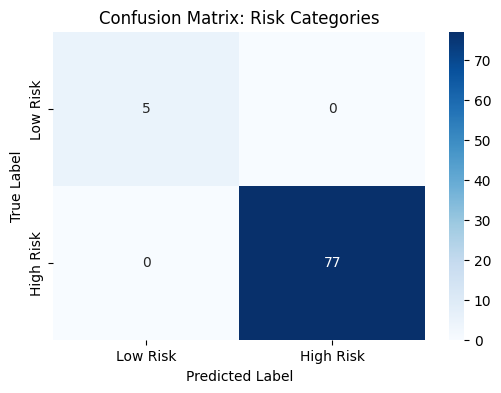

In [65]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
    xticklabels=['Low Risk', 'High Risk'], 
    yticklabels=['Low Risk', 'High Risk'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Risk Categories')
plt.show()

### Export model

In [66]:
filename = 'model1.pkl'

In [69]:
joblib.dump(lr_model, filename)

['model1.pkl']

### Import Model

In [71]:
loaded_model = joblib.load('model1.pkl')

### Checking on the model

MODEL DATA

In [86]:
min_p, max_p = 1505.92, 4485.91

In [87]:
# Calculate promise risk based on promise_date column
merged['promise_risk'] = merged['promise_date'].isna().map({True: 0.5, False: 0.1})

In [89]:
pa = int(input("Enter premium amount: "))
do = int(input("Enter days overdue: "))
pr = int(input("Enter if promise date is present (0 or 1): "))
pr = 0.5 if pr == 1 else 0.0
dr = (do / 180) * 0.3
prisk = ((pa - min_p) / (max_p - min_p)) * 0.2

In [90]:
new_data = {
    'premium_amount': pa,
    'days_overdue': do,
    'promise_risk': pr,
    'days_risk': dr,
    'premium_risk': prisk
}

In [94]:
inputdata = pd.DataFrame(new_data, index = [0])

In [95]:
lr_model.predict(inputdata)

array([0.25116947])

In [96]:
status = 'High Risk' if lr_model.predict(inputdata)[0] > 0.5 else 'Low Risk'
print(f'{status}')

Low Risk


High Risk
